In [19]:
import os
import re
import cv2
import numpy as np
import math
from PIL import Image
import matplotlib.pyplot as plt


# fmxy (7)
def fmxy(absfxy, mxy):
    return np.where(absfxy > mxy, 1, 0)

def Min(a, b):
    return np.minimum(a, b)

def G12(theta1, theta2):
    condition1 = (theta2 - np.pi < theta1) & (theta1 < theta2) & (theta2 >= 0)
    result1 = np.abs(theta1 - theta2)
    condition2 = (-np.pi < theta1) & (theta1 < (theta2 - np.pi)) & (theta2 >= 0)
    result2 = theta2 - 2 * np.pi - theta1
    condition3 = (-np.pi < theta1) & (theta1 < (theta2 + np.pi)) & (theta2 < 0)
    result3 = np.abs(theta1 - theta2)
    condition4 = (theta2 + np.pi < theta1) & (theta1 < np.pi) & (theta2 < 0)
    result4 = theta1 - theta2 - 2 * np.pi
    result = np.where(condition1, result1, 
             np.where(condition2, result2, 
             np.where(condition3, result3, 
             np.where(condition4, result4, 0))))
    return result

# 平方面積の合計 (11)(12) Tr Tm
def SquareSum(I, x, y, h, w, n):
    x1, y1 = x - n, y - n
    x2, y2 = x + n, y + n
    x1, x2 = max(x1, 0), min(x2, w - 2)
    y1, y2 = max(y1, 0), min(y2, h - 2)
    total = I[y2, x2] - I[y1, x2] - I[y2, x1] + I[y1, x1]
    return total

# sdis = Tr/Tm (13)
def sdis(Iruv, Imyv, x, y, h, w, n):
    Tr = SquareSum(Iruv, x, y, h, w, n)
    Tm = SquareSum(Imyv, x, y, h, w, n)
    return Tr / Tm

# パラメータ
n = 15

img_path = "/home/data/0203_energee_after/maskedBB/B/IMG_1703.JPEG"
mask_path = "/home/data/0203_energee_after/maskBB/B/IMG_1703.JPEG"



重心: (234.34943740827308, 260.0399086807632)


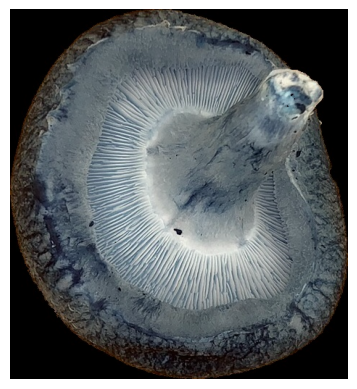

In [20]:
# 重心 (1)
img = cv2.imread(img_path)
mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
masked_img = cv2.imread(img_path)
h, w = img.shape[:2]

# 重心を計算
x_sum, y_sum, count = 0, 0, 0
for i in range(h):
    for j in range(w):
        if mask_img[i][j] == 255:
            x_sum += j
            y_sum += i
            count += 1
xc, yc = (x_sum / count, y_sum / count) if count > 0 else (0, 0)
print(f"重心: ({xc}, {yc})")
plt.axis('off')
plt.imshow(img, cmap='gray')


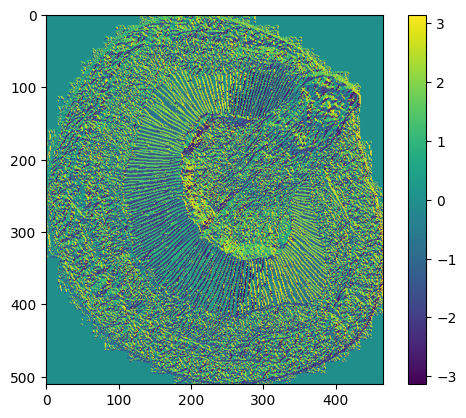

In [21]:
# fθ(x,y)(勾配の方向), |f(x,y)| (2)(3)
image = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
fdy, fdx = np.gradient(image)
f0xy = np.arctan2(fdy, fdx)
absfxy = np.uint8(np.sqrt(fdx**2 + fdy**2))

# C0(x,y)：中心からのベクトルの角度
height, width = image.shape
C0xy = np.zeros((height, width))
for y in range(height):
    for x in range(width):
        dx, dy = x - xc, y - yc
        C0xy[y, x] = np.arctan(dy / dx) if dx != 0 else 0

plt.imshow(f0xy)
plt.colorbar()

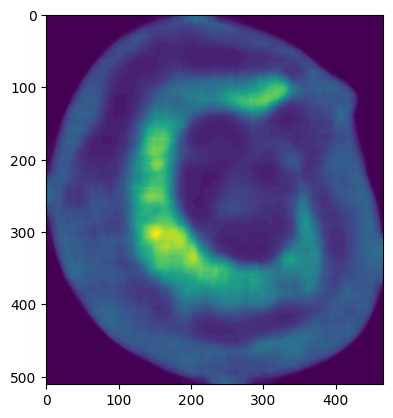

In [22]:
# f(xy)の勾配ベクトルが中心から(x,y)へのベクトルへ垂直か評価する関数fdisxy(4)(5)
fdisxy = Min(G12(C0xy + np.pi/2, f0xy)**2, G12(C0xy - np.pi/2, f0xy)**2)

# mxy = |fxy|に対する2n+1×2n+1のメディアンフィルタリングの結果
kernel_size = 2 * n + 1
mxy = np.uint8(cv2.medianBlur(absfxy, kernel_size))
plt.imshow(mxy)

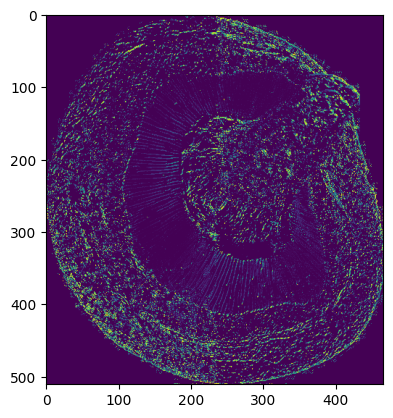

In [23]:
# rdis (8)
rdisxy = fmxy(absfxy, mxy) * fdisxy
plt.imshow(rdisxy)

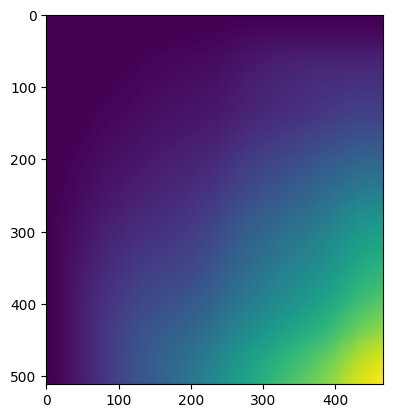

In [24]:
# Iruv, Imyv (9)(10)
Iruv = cv2.integral(rdisxy)
Imyv = cv2.integral(fmxy(absfxy, mxy).astype(np.uint8))
plt.imshow(Iruv)

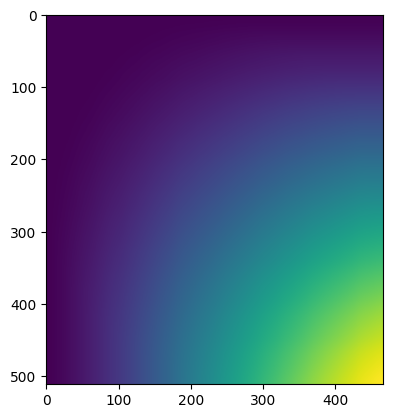

In [25]:
plt.imshow(Imyv)

/tmp/ipykernel_1126574/199445982.py:45: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/tmp/ipykernel_1126574/199445982.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


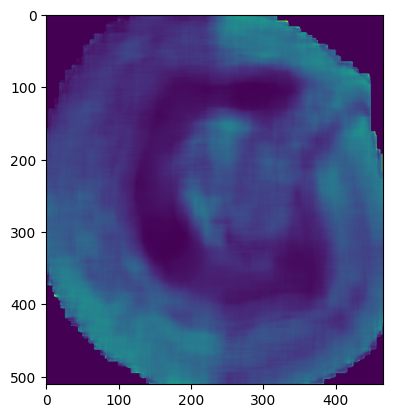

In [26]:
# sdis計算
sdisval = np.zeros((image.shape[0], image.shape[1]))
for y in range(0, image.shape[0], 1):
    for x in range(0, image.shape[1], 1):
        sdisval[y, x] = sdis(Iruv, Imyv, x, y, h, w, n)
sdisval = np.nan_to_num(sdisval, nan=0.0, posinf=0.0, neginf=0.0)
plt.imshow(sdisval)

In [27]:
# 閾値処理
T = 0.2
hxy = np.where(sdisval < T, 1, 0)
hxy2 = cv2.bitwise_and(hxy, hxy, mask=mask_img)


In [28]:
# plt.axis('off')
# plt.imshow(hxy2, cmap='gray')

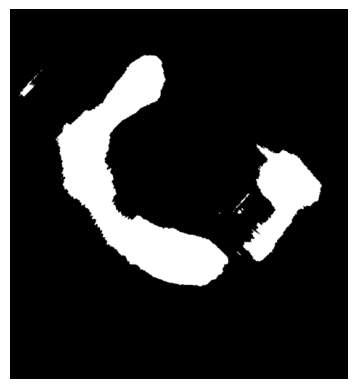

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# hxy2: 0/1 の2値画像（int32）
hxy2_uint8 = (hxy2 * 255).astype(np.uint8)

# 白領域だけのマスク画像
white_mask = (hxy2_uint8 == 255).astype(np.uint8) * 255

# 白領域だけの画像（黒背景）
white_only = cv2.bitwise_and(hxy2_uint8, hxy2_uint8, mask=white_mask)

# 画像サイズ
(h, w) = white_only.shape
center = (w // 2, h // 2)

# 回転行列（中心, 角度, 拡大率）
M = cv2.getRotationMatrix2D(center, 45, 1.0)

# 回転（背景は黒）
rotated_white = cv2.warpAffine(white_only, M, (w, h), borderValue=0)

# 表示
plt.imshow(rotated_white, cmap='gray')
plt.axis('off')
plt.show()


In [30]:
# シイタケ領域のPixel数を計算
count_mask = np.sum(mask_img == 255)
count_hida = np.sum(hxy2 == 1)
R = count_hida / count_mask if count_mask > 0 else 0
print(R)


0.17511550796325487


R（マスク内sdisの上位2つの平均）: 1.3321884534006414


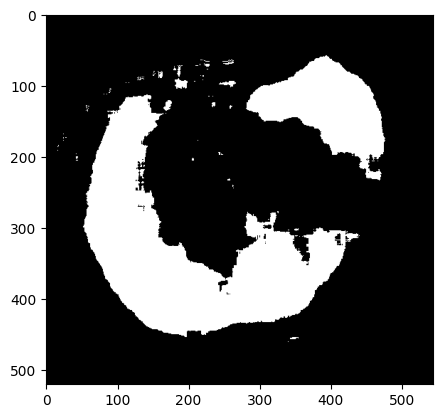

In [31]:
#sdisを使ったやつ
import os
import cv2
import numpy as np
import math
from PIL import Image
import matplotlib.pyplot as plt

# fmxy (7)
def fmxy(absfxy, mxy):
    return np.where(absfxy > mxy, 1, 0)

def Min(a, b):
    return np.minimum(a, b)

def G12(theta1, theta2):
    condition1 = (theta2 - np.pi < theta1) & (theta1 < theta2) & (theta2 >= 0)
    result1 = np.abs(theta1 - theta2)
    condition2 = (-np.pi < theta1) & (theta1 < (theta2 - np.pi)) & (theta2 >= 0)
    result2 = theta2 - 2 * np.pi - theta1
    condition3 = (-np.pi < theta1) & (theta1 < (theta2 + np.pi)) & (theta2 < 0)
    result3 = np.abs(theta1 - theta2)
    condition4 = (theta2 + np.pi < theta1) & (theta1 < np.pi) & (theta2 < 0)
    result4 = theta1 - theta2 - 2 * np.pi
    result = np.where(condition1, result1, 
             np.where(condition2, result2, 
             np.where(condition3, result3, 
             np.where(condition4, result4, 0))))
    return result

# 平方面積の合計 (11)(12) Tr Tm
def SquareSum(I, x, y, h, w, n):
    x1, y1 = x - n, y - n
    x2, y2 = x + n, y + n
    x1, x2 = max(x1, 0), min(x2, w - 2)
    y1, y2 = max(y1, 0), min(y2, h - 2)
    total = I[y2, x2] - I[y1, x2] - I[y2, x1] + I[y1, x1]
    return total

# sdis = Tr/Tm (13)
def sdis(Iruv, Imyv, x, y, h, w, n):
    Tr = SquareSum(Iruv, x, y, h, w, n)
    Tm = SquareSum(Imyv, x, y, h, w, n)
    return Tr / Tm if Tm > 0 else 0

# パラメータ
n = 10

img_path = "/home/test_hozon/combined_4_6.jpg"
mask_path = "/home/test_hozon/mask_4_6.jpg"

# 重心 (1)
img = cv2.imread(img_path)
mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
masked_img = cv2.imread(img_path)
h, w = img.shape[:2]

# 重心を計算
x_sum, y_sum, count = 0, 0, 0
for i in range(h):
    for j in range(w):
        if mask_img[i][j] == 255:
            x_sum += j
            y_sum += i
            count += 1
xc, yc = (x_sum / count, y_sum / count) if count > 0 else (0, 0)

# fθ(x,y)(勾配の方向), |f(x,y)| (2)(3)
image = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
fdy, fdx = np.gradient(image)
f0xy = np.arctan2(fdy, fdx)
absfxy = np.uint8(np.sqrt(fdx**2 + fdy**2))

# C0(x,y)：中心からのベクトルの角度
height, width = image.shape
C0xy = np.zeros((height, width))
for y in range(height):
    for x in range(width):
        dx, dy = x - xc, y - yc
        C0xy[y, x] = np.arctan(dy / dx) if dx != 0 else 0

# f(xy)の勾配ベクトルが中心から(x,y)へのベクトルへ垂直か評価する関数fdisxy(4)(5)
fdisxy = Min(G12(C0xy + np.pi/2, f0xy)**2, G12(C0xy - np.pi/2, f0xy)**2)

# mxy = |fxy|に対する2n+1×2n+1のメディアンフィルタリングの結果
kernel_size = 2 * n + 1
mxy = np.uint8(cv2.medianBlur(absfxy, kernel_size))

# rdis (8)
rdisxy = fmxy(absfxy, mxy) * fdisxy

# Iruv, Imyv (9)(10)
Iruv = cv2.integral(rdisxy)
Imyv = cv2.integral(fmxy(absfxy, mxy).astype(np.uint8))

# sdis計算
sdisval = np.zeros((image.shape[0], image.shape[1]))
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        sdisval[y, x] = sdis(Iruv, Imyv, x, y, h, w, n)

# nanやinfを0に
sdisval = np.nan_to_num(sdisval, nan=0.0, posinf=0.0, neginf=0.0)

# hxy2 = 閾値処理（ただし最終Rには使わない）
T = 0.2
hxy = np.where(sdisval < T, 1, 0)
hxy2 = cv2.bitwise_and(hxy, hxy, mask=mask_img)
plt.imshow(hxy2, cmap='gray')

# --- R値の決定（マスク内のsdis値のうち最大4つから上位2つの平均）---
masked_sdis = sdisval[mask_img == 255]
if len(masked_sdis) >= 2:
    top4 = np.sort(masked_sdis)[-4:]  # 最大4つ
    R = np.mean(top4[-2:])  # 最大2つの平均
else:
    R = 0.0

print(f"R（マスク内sdisの上位2つの平均）: {R}")


In [32]:
#R値を使ったやつ
import os
import re
import cv2
import numpy as np
import math
from PIL import Image
import matplotlib.pyplot as plt

# fmxy (7): |f(x,y)| が mxy より大きい場合に 1, そうでなければ 0 を返す
def fmxy(absfxy, mxy):
    return np.where(absfxy > mxy, 1, 0)

# 2つの配列の要素ごとの最小値を返す
def Min(a, b):
    return np.minimum(a, b)

# G12: 2つの角度の差（特定の条件下での絶対差や補正値）を計算
def G12(theta1, theta2):
    condition1 = (theta2 - np.pi < theta1) & (theta1 < theta2) & (theta2 >= 0)
    result1 = np.abs(theta1 - theta2)
    condition2 = (-np.pi < theta1) & (theta1 < (theta2 - np.pi)) & (theta2 >= 0)
    result2 = theta2 - 2 * np.pi - theta1
    condition3 = (-np.pi < theta1) & (theta1 < (theta2 + np.pi)) & (theta2 < 0)
    result3 = np.abs(theta1 - theta2)
    condition4 = (theta2 + np.pi < theta1) & (theta1 < np.pi) & (theta2 < 0)
    result4 = theta1 - theta2 - 2 * np.pi
    result = np.where(condition1, result1, 
             np.where(condition2, result2, 
             np.where(condition3, result3, 
             np.where(condition4, result4, 0))))
    return result

# 平方面積の合計 (11)(12): 積分画像を利用して矩形領域の画素和を求める
def SquareSum(I, x, y, h, w, n):
    # 対象矩形領域の左上と右下の座標
    x1, y1 = x - n, y - n
    x2, y2 = x + n, y + n
    # 画像境界内に収める
    x1, x2 = max(x1, 0), min(x2, w - 2)
    y1, y2 = max(y1, 0), min(y2, h - 2)
    total = I[y2, x2] - I[y1, x2] - I[y2, x1] + I[y1, x1]
    return total

# sdis = Tr/Tm (13): 指定領域での評価値計算
def sdis(Iruv, Imyv, x, y, h, w, n):
    Tr = SquareSum(Iruv, x, y, h, w, n)
    Tm = SquareSum(Imyv, x, y, h, w, n)
    return Tr / Tm

# パラメータ設定
n = 15  # メディアンフィルタや積分画像で用いる窓サイズ
img_path = "/home/data/jikuari_maesyori/combined/collage_1/combined_1_3.jpg"
mask_path = "/home/data/jikuari_maesyori/mask/collage_1/mask_1_3.jpg"

# 画像の読み込み
img = cv2.imread(img_path)
mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
masked_img = cv2.imread(img_path)
h, w = img.shape[:2]

# マスク（シイタケ領域）の重心 (1) を計算
x_sum, y_sum, count = 0, 0, 0
for i in range(h):
    for j in range(w):
        if mask_img[i][j] == 255:
            x_sum += j
            y_sum += i
            count += 1
xc, yc = (x_sum / count, y_sum / count) if count > 0 else (0, 0)
# 重心の整数値（画像分割用）
xc_int, yc_int = int(round(xc)), int(round(yc))

# fθ(x,y)（勾配の方向）と |f(x,y)|（勾配の大きさ）を計算 (2)(3)
image = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
fdy, fdx = np.gradient(image)
f0xy = np.arctan2(fdy, fdx)
absfxy = np.uint8(np.sqrt(fdx**2 + fdy**2))

# C0(x,y)：重心から各画素へのベクトルの角度を求める
height, width = image.shape
C0xy = np.zeros((height, width))
for y in range(height):
    for x in range(width):
        dx, dy = x - xc, y - yc
        # dxがゼロの場合は 0 とする（もしくは適宜処理）
        C0xy[y, x] = np.arctan(dy / dx) if dx != 0 else 0

# f(x,y)の勾配ベクトルが、重心から各画素へのベクトルに対して垂直かを評価 (4)(5)
fdisxy = Min(G12(C0xy + np.pi/2, f0xy)**2, G12(C0xy - np.pi/2, f0xy)**2)

# mxy: |f(x,y)| に対し、2n+1×2n+1 のメディアンフィルタリング結果
kernel_size = 2 * n + 1
mxy = np.uint8(cv2.medianBlur(absfxy, kernel_size))

# rdis (8): 閾値処理を含む評価マップの計算
rdisxy = fmxy(absfxy, mxy) * fdisxy

# Iruv, Imyv: 積分画像を用いて、局所領域ごとの累積値を計算 (9)(10)
Iruv = cv2.integral(rdisxy)
Imyv = cv2.integral(fmxy(absfxy, mxy).astype(np.uint8))

# sdis計算: 画像全体に対して画素ごとに評価値を求める
sdisval = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        sdisval[y, x] = sdis(Iruv, Imyv, x, y, h, w, n)
sdisval = np.nan_to_num(sdisval, nan=0.0, posinf=0.0, neginf=0.0)

# 閾値処理: 評価値が T 以下なら 1, それ以外なら 0 とする
T = 0.2
hxy = np.where(sdisval < T, 1, 0)
# マスク画像の領域に限定して AND 演算
hxy2 = cv2.bitwise_and(hxy, hxy, mask=mask_img)
plt.imshow(hxy2, cmap='gray')

# 画像を重心 (xc, yc) で4分割して各領域における R 値を計算する
# 分割は、上部・下部、左部・右部に分ける
# ※各領域は、mask_img でシイタケ領域となっている画素に限定する
# 各領域のインデックスは、整数に丸めた重心座標 (xc_int, yc_int) を用いる

# 上左領域：y:0〜yc_int, x:0〜xc_int
mask_ul = mask_img[0:yc_int, 0:xc_int]
hida_ul = hxy2[0:yc_int, 0:xc_int]
count_mask_ul = np.sum(mask_ul == 255)
count_hida_ul = np.sum(hida_ul == 1)
R_ul = count_hida_ul / count_mask_ul if count_mask_ul > 0 else 0

# 上右領域：y:0〜yc_int, x:xc_int〜w
mask_ur = mask_img[0:yc_int, xc_int:w]
hida_ur = hxy2[0:yc_int, xc_int:w]
count_mask_ur = np.sum(mask_ur == 255)
count_hida_ur = np.sum(hida_ur == 1)
R_ur = count_hida_ur / count_mask_ur if count_mask_ur > 0 else 0

# 下左領域：y:yc_int〜h, x:0〜xc_int
mask_ll = mask_img[yc_int:h, 0:xc_int]
hida_ll = hxy2[yc_int:h, 0:xc_int]
count_mask_ll = np.sum(mask_ll == 255)
count_hida_ll = np.sum(hida_ll == 1)
R_ll = count_hida_ll / count_mask_ll if count_mask_ll > 0 else 0

# 下右領域：y:yc_int〜h, x:xc_int〜w
mask_lr = mask_img[yc_int:h, xc_int:w]
hida_lr = hxy2[yc_int:h, xc_int:w]
count_mask_lr = np.sum(mask_lr == 255)
count_hida_lr = np.sum(hida_lr == 1)
R_lr = count_hida_lr / count_mask_lr if count_mask_lr > 0 else 0

# 4領域のR値の中から最大のものを採用する
R_values = [R_ul, R_ur, R_ll, R_lr]
average_top2 = sum(sorted(R_values, reverse=True)[:2]) / 2
Rh = max(R_values)
count_mask = np.sum(mask_img == 255)
count_hida = np.sum(hxy2 == 1)
R = count_hida / count_mask if count_mask > 0 else 0
print(count_mask)
print(count_hida)
# 結果表示
print("上位2つの平均:", average_top2)
print("R値:", R)
print("R_ul:", R_ul)
print("R_ur:", R_ur)
print("R_ll:", R_ll)
print("R_lr:", R_lr)


[ WARN:0@42.609] global loadsave.cpp:248 findDecoder imread_('/home/data/jikuari_maesyori/combined/collage_1/combined_1_3.jpg'): can't open/read file: check file path/integrity
[ WARN:0@42.609] global loadsave.cpp:248 findDecoder imread_('/home/data/jikuari_maesyori/mask/collage_1/mask_1_3.jpg'): can't open/read file: check file path/integrity
[ WARN:0@42.610] global loadsave.cpp:248 findDecoder imread_('/home/data/jikuari_maesyori/combined/collage_1/combined_1_3.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
import hida
a = hida.Hida_file_jikuari(img_path="/home/data/jikuari_maesyori/combined/collage_1/combined_1_3.jpg",
                                     mask_path="/home/data/jikuari_maesyori/mask/collage_1/mask_1_3.jpg",
                                     n=15, T=0.2)
result = a.main()
print(result)

/usr/local/lib/python3.11/site-packages/hida/__main__.py:494: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/usr/local/lib/python3.11/site-packages/hida/__main__.py:494: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


AttributeError: 'Hida_syuho' object has no attribute 'w'

In [ ]:
import hida
a = hida.Hida_folder_jikuari(base_dir="/home/data/jikuari_maesyori")
result = a.run_all()
print(result)

In [ ]:
import hida
a = hida.Hida_file(img_path="/home/data/jikuari_maesyori/combined/collage_1/combined_1_3.jpg",
                                     mask_path="/home/data/jikuari_maesyori/mask/collage_1/mask_1_3.jpg",
                                     n=15, T=0.2)
result = a.run()
print(result)


In [ ]:
import hida
a = hida.Hida_folder(base_dir="/home/data/jikuari_maesyori",n=15, T=0.2)
result = a.run_all()
print(result)